# Fake News Detection Pipeline (v2)

This notebook demonstrates a streamlined pipeline for fake news detection:

1. **Data Processing**: Load raw data, clean source attribution, remove duplicates
2. **Train/Test Split**: Stratified split with configurable columns
3. **Feature Engineering**: TF-IDF vectorization
4. **Model Training**: Ridge Classifier and Logistic Regression
5. **Feature Importance**: Analyze what drives predictions

**Key improvement**: Feature and label columns are now explicitly configured and logged at each step.


In [1]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import modules (with reload to pick up any changes)
from src.data import process_dataset, make_split
from src.features import make_features
from src.models import train_model as train_model_module

importlib.reload(make_features)
importlib.reload(train_model_module)

run_feature_engineering = make_features.run_feature_engineering
train_model = train_model_module.train_model
load_config = train_model_module.load_config

print("✓ Imports successful")


✓ Imports successful


In [2]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'


## 1. Data Processing

Load raw data, clean source attribution (e.g., "(Reuters) -"), and remove duplicates.


In [3]:
# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
cleaned_data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

# Process dataset: load, clean source attribution, deduplicate
df = process_dataset(
    input_path=str(raw_data_path),
    output_path=str(cleaned_data_path),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    id_column=ID_COLUMN
)


DATA PROCESSING
Input:  /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

1. Loading dataset...
   Loaded 72,134 rows
   Columns: ['id', 'title', 'text', 'label']

2. Cleaning source attribution from 'text' column...
   Removing patterns like '(Reuters) -', '(AP) -', etc.
   ✓ Source attribution removed

3. Removing duplicate articles (based on 'text')...
   Removed 27,695 duplicates
   Remaining: 44,439 unique articles

4. Label distribution ('label' column):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

5. Saving cleaned data...
✓ Saved 44439 rows to /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

✓ DATA PROCESSING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Total rows:     44,439
  Saved to:       /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv


## 2. Train/Test Split

Create stratified train/test split (80/20) based on label column.


In [4]:
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(cleaned_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"],
    label_column=LABEL_COLUMN,
    feature_column=FEATURE_COLUMN
)


TRAIN/TEST SPLIT

1. Loading data from /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv...
   Loaded 44,439 rows

2. Validating columns...
   Feature column (X): 'text'
   Label column (y):   'label'
   ✓ All required columns present

3. Label distribution (before split):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

4. Splitting data (test_size=0.2, random_seed=42)...

5. Saving splits...
   Train: /Users/alanye/Fake-News-Group-3/data/processed/train.csv (35,551 rows)
   Test:  /Users/alanye/Fake-News-Group-3/data/processed/test.csv (8,888 rows)

✓ SPLIT COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Train samples:  35,551
  Test samples:   8,888


In [5]:
test_df

,id,title,text,label
4567,6728,U.S. says holds Myanmar military leaders accou...,U.S. Secretary of State Rex Tillerson said on ...,0
43904,71182,Why America might elect a president it doesn't...,Donald Trump and Hillary Clinton have among th...,0
7859,11556,N. DAKOTA LEGISLATOR Proposes Bill To PROTECT ...,Protesters who take to the streets in North Da...,1
40372,64766,"Speaker David Gowan Reshapes Arizona House, Fr...",PHOENIX — When lawmakers in the Arizona Hou...,0
4774,7036,Can The American People Defeat The Oligarchy T...,"SPECIAL TO BUSINESS WEEK, MINDY KATZMAN, AUTH....",1
...,...,...,...,...
19124,29034,“COMEDIAN” GEORGE LOPEZ Who Said About Trump S...,"When a woman in the audience objected, Lopez w...",1
10053,14931,TRUMP EXPOSES OBAMA’S INCOMPETENCE: Cuts EPA B...,Although Obama had 3 years to take action to f...,1
904,1326,Putin warns U.S. not to supply Ukraine with de...,Russian President Vladimir Putin said on Tuesd...,0
42368,68420,"UK's Johnson has ""constructive"" call with husb...",British foreign minister Boris Johnson had a ...,0


In [6]:
train_df

,id,title,text,label
1314,1921,YIKES! 30 Years Of HILLARY’S LIES Have Driven ...,This is not a fluke. After years of towing the...,1
8906,13144,The Fake News About Central Banking,The Fake News About Central Banking By Daily B...,1
30809,47995,Fact checking the fourth round of GOP debates,Fox Business News aired two GOP presidential d...,0
10085,14979,"On Campus, Trump Fans Say They Need ‘Safe Spac...","ANN ARBOR, Mich. — Amanda Delekta, a sophom...",0
30494,47478,Microsoft unveils sleek desktop computer,Microsoft unveils sleek desktop computer Re: M...,1
...,...,...,...,...
26399,40675,Puerto Rico may issue delayed audited 2014 sta...,Puerto Rico’s much-delayed audited financial s...,0
23164,35397,Merkel can well imagine a European finance min...,German Chancellor Angela Merkel said on Friday...,0
13567,20347,ATF misfire? Guide indicates bullets at center...,It looked like the fix was in. But the ATF say...,0
2279,3323,French foreign minister visits Libya in new pu...,Libya s rival factions should stick to a Unite...,0


## 3. Feature Engineering

Convert text to TF-IDF vectors (unigrams + bigrams, max 5000 features).


In [7]:
run_feature_engineering(
    processed_dir=str(processed_dir),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    max_features=config["features"]["tfidf"]["max_features"]
)


FEATURE ENGINEERING

1. Loading train/test split...

2. Extracting features and labels...
   Feature column (X): 'text'
   Label column (y):   'label'

   Train samples: 35,551
   Test samples:  8,888

   Label distribution (train):
     0 (Real): 23,649 (66.5%)
     1 (Fake): 11,902 (33.5%)

3. Creating TF-IDF features...
   Max features: 5,000
   N-gram range: (1, 2)
   ✓ Train TF-IDF shape: (35551, 5000)
   ✓ Test TF-IDF shape:  (8888, 5000)

4. Creating Word2Vec/Sentence2Vec features...
   Training Word2Vec model...
   Generating sentence vectors...
   ✓ Train W2V shape: (35551, 100)
   ✓ Test W2V shape:  (8888, 100)

5. Saving features to /Users/alanye/Fake-News-Group-3/data/processed...
   ✓ TF-IDF features saved
   ✓ Word2Vec features saved

✓ FEATURE ENGINEERING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  TF-IDF shape:   (35551, 5000)
  Word2Vec shape: (35551, 100)


## 4. Model Training

Train Ridge Classifier and Logistic Regression models.


In [8]:
# Train LightGBM Classifier
lgbm_model, lgbm_metrics, lgbm_preds = train_model(
    "lgbm", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


MODEL TRAINING: lgbm

1. Loading features and labels...
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_train_tfidf.npz
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_test_tfidf.npz

2. Data summary:
   Feature source: 'text' column → TF-IDF vectors
   Label source:   'label' column (0=Real, 1=Fake)

   X_train shape: (35551, 5000)
   X_test shape:  (8888, 5000)

   Label distribution:
     Train: 0=23649, 1=11902
     Test: 0=5912, 1=2976

3. Initializing lgbm...
   Parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 31, 'objective': 'binary'}

4. Training model...
[LightGBM] [Info] Number of positive: 11902, number of negative: 23649
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.675834 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 963590
[LightGBM] [Info] Number of data points in the train set: 35551, number of used features: 5000
[

In [10]:
# Display LGBM metrics summary
print("=" * 60)
print("LGBM MODEL SUMMARY")
print("=" * 60)
print(f"Accuracy: {lgbm_metrics['accuracy']:.4f}")
print(f"\nPrecision (Fake): {lgbm_metrics['report']['1']['precision']:.4f}")
print(f"Recall (Fake): {lgbm_metrics['report']['1']['recall']:.4f}")
print(f"F1-score (Fake): {lgbm_metrics['report']['1']['f1-score']:.4f}")


LGBM MODEL SUMMARY
Accuracy: 0.9307

Precision (Fake): 0.9114
Recall (Fake): 0.8784
F1-score (Fake): 0.8946


In [11]:
import numpy as np
import pandas as pd
import joblib

# Load the training features
train_data = np.load("../data/processed/features_train_tfidf.npz", allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

print("X_train (Features):")
print(f"  Shape: {X_train.shape}")
print(f"  Type: {type(X_train)}")

print("\ny_train (Labels):")
print(f"  Shape: {y_train.shape}")
print(f"  Values: {np.unique(y_train, return_counts=True)}")

# Show sample
vectorizer = joblib.load("../data/processed/tfidf_vectorizer.pkl")
feature_names = vectorizer.get_feature_names_out()

sample_row = X_train[0].toarray().flatten()
nonzero = np.where(sample_row > 0)[0]
print(f"\nSample row 0 (label={y_train[0]}):")
print(f"  Non-zero features: {len(nonzero)}")
print(f"  Top features: {[(feature_names[i], f'{sample_row[i]:.3f}') for i in nonzero[np.argsort(sample_row[nonzero])[-5:]]]}")

X_train (Features):
  Shape: (35551, 5000)
  Type: <class 'scipy.sparse._csr.csr_matrix'>

y_train (Labels):
  Shape: (35551,)
  Values: (array([0, 1]), array([23649, 11902]))

Sample row 0 (label=1):
  Non-zero features: 16
  Top features: [('poll', '0.276'), ('bernie', '0.282'), ('bernie sanders', '0.286'), ('combined', '0.337'), ('union', '0.438')]


In [12]:
import numpy as np
import pandas as pd
import joblib

# Load the training features
train_data = np.load(str(processed_dir / "features_train_tfidf.npz"), allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

# Load vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

# Convert sparse matrix to DataFrame (first 100 rows to avoid memory issues)
n_samples = 100
X_sample = X_train[:n_samples].toarray()

df_features = pd.DataFrame(X_sample, columns=feature_names)
df_features.insert(0, 'label', y_train[:n_samples])

print(f"Shape: {df_features.shape}")
print(f"Columns: label + {len(feature_names)} TF-IDF features")
print(f"\nFirst 5 rows, first 10 columns:")
display(df_features.iloc[:5, :10])

# Show non-zero features for first sample
print(f"\nSample 0 (label={y_train[0]}) - Non-zero features:")
row = df_features.iloc[0, 1:]  # Exclude label column
nonzero = row[row > 0].sort_values(ascending=False)
print(nonzero.head(20))

Shape: (100, 5001)
Columns: label + 5000 TF-IDF features

First 5 rows, first 10 columns:


,label,000,000 people,10,10 000,10 percent,10 years,100,100 000,11
0,1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
1,1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
2,0,0.103995,0.0,0.145727,0.0,0.041099,0.0,0.013626,0.019944,0.039448
3,0,0.014065,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
4,1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000



Sample 0 (label=1) - Non-zero features:
union             0.438494
combined          0.337488
bernie sanders    0.286433
bernie            0.281687
poll              0.275806
sanders           0.271404
trump             0.255729
democrat          0.227359
line              0.219756
life              0.202198
members           0.188163
recent            0.186466
hillary           0.178556
support           0.166776
long              0.164246
years             0.139962
Name: 0, dtype: float64


### Model Evaluation & Confusion Matrix


LGBM MODEL EVALUATION

Features used: 'text' column → TF-IDF
Labels used:   'label' column (0=Real, 1=Fake)

LGBM Classifier Accuracy: 0.9307

Classification Report:
  Real (0):
    Precision: 0.9399
    Recall:    0.9570
    F1-score:  0.9484
  Fake (1):
    Precision: 0.9114
    Recall:    0.8784
    F1-score:  0.8946


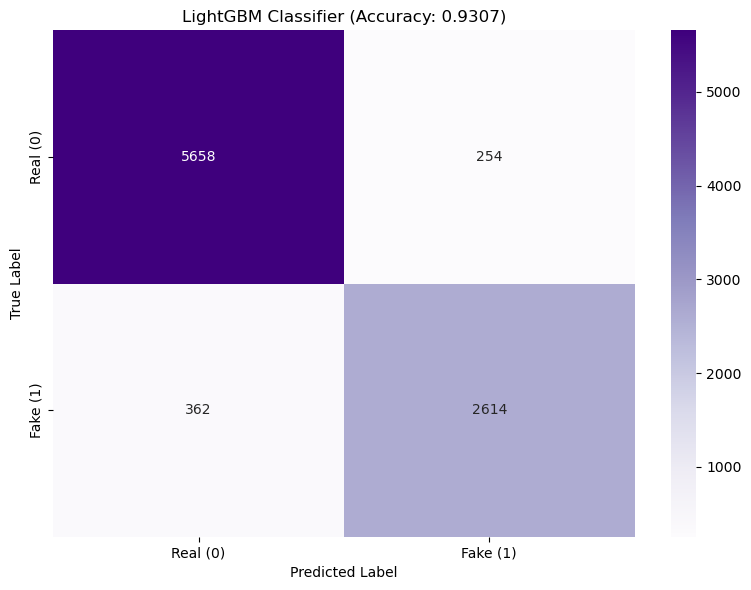

In [14]:
print("=" * 60)
print("LGBM MODEL EVALUATION")
print("=" * 60)
print(f"\nFeatures used: '{lgbm_metrics['feature_column']}' column → TF-IDF")
print(f"Labels used:   '{lgbm_metrics['label_column']}' column (0=Real, 1=Fake)")
print(f"\nLGBM Classifier Accuracy: {lgbm_metrics['accuracy']:.4f}")

# Classification metrics
print(f"\nClassification Report:")
for label, name in [('0', 'Real (0)'), ('1', 'Fake (1)')]:
    print(f"  {name}:")
    print(f"    Precision: {lgbm_metrics['report'][label]['precision']:.4f}")
    print(f"    Recall:    {lgbm_metrics['report'][label]['recall']:.4f}")
    print(f"    F1-score:  {lgbm_metrics['report'][label]['f1-score']:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))

# LGBM Confusion Matrix
sns.heatmap(lgbm_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
ax.set_title(f"LightGBM Classifier (Accuracy: {lgbm_metrics['accuracy']:.4f})")
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis

Analyze which words/n-grams are most predictive of fake vs real news using multiple methods:

1. **MDI (Mean Decrease in Impurity)**: LGBM's built-in `feature_importances_` based on gain
2. **Permutation Feature Importance**: Measures importance by shuffling features and observing accuracy drop
3. **SHAP (SHapley Additive exPlanations)**: Game-theoretic approach for consistent feature attributions


In [17]:
import joblib
from sklearn.inspection import permutation_importance

# Load the TF-IDF vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

# Load test data for permutation importance
test_data = np.load(str(processed_dir / "features_test_tfidf.npz"), allow_pickle=True)
X_test = test_data["X"]
if hasattr(X_test, 'item'):  # Handle 0-d array wrapping sparse matrix
    X_test = X_test.item()
y_test = test_data["y"]

print("=" * 60)
print("1. MDI (Mean Decrease in Impurity) Feature Importance")
print("   (Built-in LGBM feature_importances_ based on gain)")
print("=" * 60)

# MDI Feature Importance (built-in)
mdi_importances = lgbm_model.feature_importances_
mdi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mdi_importances
}).sort_values('importance', ascending=False)

print(f"\nTop 20 features by MDI:")
print(mdi_df.head(20).to_string(index=False))


1. MDI (Mean Decrease in Impurity) Feature Importance
   (Built-in LGBM feature_importances_ based on gain)

Top 20 features by MDI:
         feature  importance
            said          59
         hillary          54
            2016          50
              mr          40
president donald          36
        thursday          35
         october          34
          monday          34
          friday          34
       wednesday          29
          sunday          29
         tuesday          29
        november          26
         america          24
         percent          23
            just          23
      republican          23
        minister          23
          entire          21
             fbi          21


In [21]:
print("\n" + "=" * 60)
print("2. Permutation Feature Importance")
print("   (Measures accuracy drop when shuffling features)")
print("=" * 60)

# Use a sample for permutation importance (sparse to dense conversion requires memory)
perm_sample_size = min(2000, X_test.shape[0])
print(f"\nUsing {perm_sample_size} samples for permutation importance...")

# Convert sparse to dense for the sample
if hasattr(X_test, 'toarray'):
    X_test_sample = X_test[:perm_sample_size].toarray()
else:
    X_test_sample = X_test[:perm_sample_size]
y_test_sample = y_test[:perm_sample_size]

print("Computing permutation importance (this may take a moment)...")
perm_result = permutation_importance(
    lgbm_model, X_test_sample, y_test_sample, 
    n_repeats=10, random_state=42, n_jobs=-1, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"\nTop 20 features by Permutation Importance:")
print(perm_df.head(20).to_string(index=False))



2. Permutation Feature Importance
   (Measures accuracy drop when shuffling features)

Using 2000 samples for permutation importance...
Computing permutation importance (this may take a moment)...

Top 20 features by Permutation Importance:
         feature  importance_mean  importance_std
            said          0.04615        0.005225
         hillary          0.01020        0.001584
              mr          0.00805        0.001457
president donald          0.00580        0.002147
        thursday          0.00565        0.001659
          friday          0.00440        0.001044
         tuesday          0.00345        0.001150
          monday          0.00310        0.001136
            2016          0.00305        0.001293
          entire          0.00285        0.000709
         october          0.00275        0.000680
              ms          0.00255        0.000907
             fbi          0.00235        0.000923
         reuters          0.00230        0.000954
        

In [22]:
print("\n" + "=" * 60)
print("3. SHAP (SHapley Additive exPlanations)")
print("   (Game-theoretic feature attributions)")
print("=" * 60)

try:
    import shap
    
    # Use a sample of test data for SHAP (to keep computation manageable)
    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test[:sample_size].toarray()  # Convert sparse to dense for SHAP
    
    print(f"\nComputing SHAP values on {sample_size} samples...")
    
    # Create SHAP explainer for tree-based model
    explainer = shap.TreeExplainer(lgbm_model)
    shap_values = explainer.shap_values(X_sample)
    
    # For binary classification, take absolute mean of SHAP values
    if isinstance(shap_values, list):
        # Binary classification returns [class0_shap, class1_shap]
        shap_importance = np.abs(shap_values[1]).mean(axis=0)
    else:
        shap_importance = np.abs(shap_values).mean(axis=0)
    
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance
    }).sort_values('shap_importance', ascending=False)
    
    print(f"\nTop 20 features by SHAP importance:")
    print(shap_df.head(20).to_string(index=False))
    
    shap_available = True
except ImportError:
    print("\nSHAP library not installed. Install with: pip install shap")
    shap_available = False
except Exception as e:
    print(f"\nError computing SHAP values: {e}")
    shap_available = False



3. SHAP (SHapley Additive exPlanations)
   (Game-theoretic feature attributions)

Computing SHAP values on 1000 samples...

Top 20 features by SHAP importance:
         feature  shap_importance
            said         1.034257
         hillary         0.246760
president donald         0.232078
            2016         0.181508
              mr         0.130782
        thursday         0.119160
          friday         0.110085
            just         0.110037
         tuesday         0.105456
        minister         0.101459
          monday         0.093744
       wednesday         0.091351
         october         0.086329
       president         0.084831
         america         0.079606
            anti         0.077916
         percent         0.077757
      republican         0.077744
             new         0.071727
          sunday         0.070575


/Users/alanye/miniconda3/envs/fake-news-detection/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


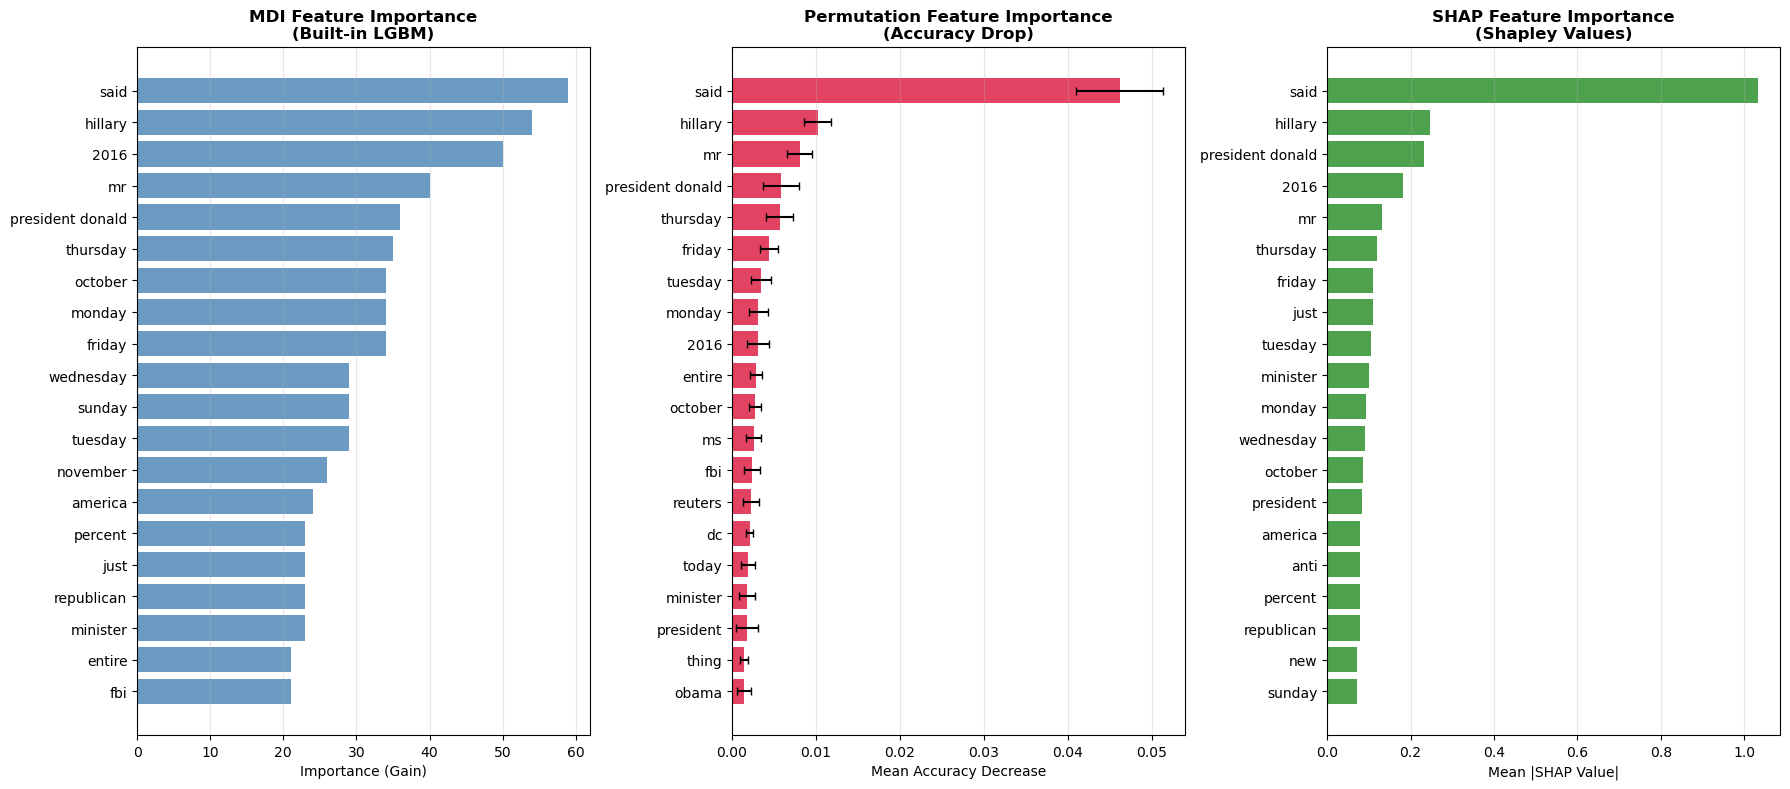


Figure saved to: results/figures/lgbm_feature_importance_comparison.png


In [23]:
# Visualize feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# MDI Feature Importance
ax1 = axes[0]
top_mdi = mdi_df.head(20)
y_pos = np.arange(len(top_mdi))
ax1.barh(y_pos, top_mdi['importance'].values, color='steelblue', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_mdi['feature'].values)
ax1.invert_yaxis()
ax1.set_xlabel('Importance (Gain)')
ax1.set_title('MDI Feature Importance\n(Built-in LGBM)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Permutation Feature Importance
ax2 = axes[1]
top_perm = perm_df.head(20)
y_pos = np.arange(len(top_perm))
ax2.barh(y_pos, top_perm['importance_mean'].values, color='crimson', alpha=0.8, 
         xerr=top_perm['importance_std'].values, capsize=3)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_perm['feature'].values)
ax2.invert_yaxis()
ax2.set_xlabel('Mean Accuracy Decrease')
ax2.set_title('Permutation Feature Importance\n(Accuracy Drop)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# SHAP Feature Importance
ax3 = axes[2]
if shap_available:
    top_shap = shap_df.head(20)
    y_pos = np.arange(len(top_shap))
    ax3.barh(y_pos, top_shap['shap_importance'].values, color='forestgreen', alpha=0.8)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(top_shap['feature'].values)
    ax3.invert_yaxis()
    ax3.set_xlabel('Mean |SHAP Value|')
    ax3.set_title('SHAP Feature Importance\n(Shapley Values)', fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'SHAP not available', ha='center', va='center', fontsize=14)
    ax3.set_title('SHAP Feature Importance', fontweight='bold')

plt.tight_layout()
plt.savefig(str(project_root / "results" / "figures" / "lgbm_feature_importance_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure saved to: results/figures/lgbm_feature_importance_comparison.png")


In [24]:
# Feature importance overlap analysis
print("=" * 60)
print("FEATURE IMPORTANCE METHODS COMPARISON")
print("=" * 60)

# Get top 20 features from each method
mdi_top20 = set(mdi_df.head(20)['feature'].values)
perm_top20 = set(perm_df.head(20)['feature'].values)

if shap_available:
    shap_top20 = set(shap_df.head(20)['feature'].values)
    
    # Find overlapping features
    all_methods_overlap = mdi_top20 & perm_top20 & shap_top20
    mdi_perm_overlap = mdi_top20 & perm_top20
    mdi_shap_overlap = mdi_top20 & shap_top20
    perm_shap_overlap = perm_top20 & shap_top20
    
    print(f"\nFeatures in Top 20 across ALL methods ({len(all_methods_overlap)}/20):")
    print(sorted(all_methods_overlap))
    print(f"\nMDI & Permutation overlap: {len(mdi_perm_overlap)}/20")
    print(f"MDI & SHAP overlap: {len(mdi_shap_overlap)}/20")
    print(f"Permutation & SHAP overlap: {len(perm_shap_overlap)}/20")
else:
    mdi_perm_overlap = mdi_top20 & perm_top20
    print(f"\nMDI & Permutation overlap ({len(mdi_perm_overlap)}/20):")
    print(sorted(mdi_perm_overlap))

# Final summary
print("\n" + "=" * 60)
print("LGBM EXPERIMENT SUMMARY")
print("=" * 60)
print(f"\nModel: LightGBM Classifier")
print(f"Features: TF-IDF ({len(feature_names)} features)")
print(f"Accuracy: {lgbm_metrics['accuracy']:.4f}")
print(f"\nClassification Report:")
for label, name in [('0', 'Real (0)'), ('1', 'Fake (1)')]:
    print(f"  {name}:")
    print(f"    Precision: {lgbm_metrics['report'][label]['precision']:.4f}")
    print(f"    Recall:    {lgbm_metrics['report'][label]['recall']:.4f}")
    print(f"    F1-score:  {lgbm_metrics['report'][label]['f1-score']:.4f}")

print(f"\nTop 10 Features by MDI:")
for i, (_, row) in enumerate(mdi_df.head(10).iterrows(), 1):
    print(f"  {i}. {row['feature']}: {row['importance']:.0f}")

print(f"\nTop 10 Features by Permutation Importance:")
for i, (_, row) in enumerate(perm_df.head(10).iterrows(), 1):
    print(f"  {i}. {row['feature']}: {row['importance_mean']:.4f} (±{row['importance_std']:.4f})")


FEATURE IMPORTANCE METHODS COMPARISON

Features in Top 20 across ALL methods (11/20):
['2016', 'friday', 'hillary', 'minister', 'monday', 'mr', 'october', 'president donald', 'said', 'thursday', 'tuesday']

MDI & Permutation overlap: 13/20
MDI & SHAP overlap: 17/20
Permutation & SHAP overlap: 12/20

LGBM EXPERIMENT SUMMARY

Model: LightGBM Classifier
Features: TF-IDF (5000 features)
Accuracy: 0.9307

Classification Report:
  Real (0):
    Precision: 0.9399
    Recall:    0.9570
    F1-score:  0.9484
  Fake (1):
    Precision: 0.9114
    Recall:    0.8784
    F1-score:  0.8946

Top 10 Features by MDI:
  1. said: 59
  2. hillary: 54
  3. 2016: 50
  4. mr: 40
  5. president donald: 36
  6. thursday: 35
  7. october: 34
  8. monday: 34
  9. friday: 34
  10. wednesday: 29

Top 10 Features by Permutation Importance:
  1. said: 0.0461 (±0.0052)
  2. hillary: 0.0102 (±0.0016)
  3. mr: 0.0080 (±0.0015)
  4. president donald: 0.0058 (±0.0021)
  5. thursday: 0.0056 (±0.0017)
  6. friday: 0.0044 (